In [79]:
#Core imports
import warnings
#warnings.filterwarnings('ignore  ') #ignores warnings if there are any errors in the code

import pandas as pd
import numpy as np
import os
from datetime import datetime #imports and allows you to access all functions related to seeing the date and time in your code

#Visuations
import matplotlib.pyplot as plt
import seaborn as sns #imports a high level data visualisation module into python

#ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder #LabelEncoder turns categorical data (Malaysia, UK, Brunei) into numerical data (0,1,2)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try: #executes this command only in this specific block, and if it fails it sets the variable as False
    from xgboost import XGBRegressor #xgboost is another ML library that works on gradient boosting
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except:
    LIGHTGBM_AVAILABLE = False
    
#Configuration
plt.style.use('seaborn-v0_8-darkgrid') #mimics darkgrid featuring dark gray background and white grid lines
sns.set_palette("husl") #generates well balanced equally intense colour space
pd.set_option('display.max_columns', None) #shows all columns, preventing truncation (shortening a number)
pd.set_option('display.precision', 2) #sets floating point precision to 2 decimal places
np.random.seed(42) #creates reproducible work

print("Environment Setup Complete")
print(f" XGBOOST: {'Available' if XGBOOST_AVAILABLE else 'Not Available'}")
print(f" LightGBM: {'Available' if LIGHTGBM_AVAILABLE else 'Not Available'}")
print(f" Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Environment Setup Complete
 XGBOOST: Available
 LightGBM: Available
 Analysis Date: 2026-02-17 17:17:54


In [80]:
#Load in Directory
import os
os.chdir(r"C:\Users\Idris\OneDrive - Imperial College London\Machine Learning\Personal Projects")

#Load Dataset
df = pd.read_csv('price_of_healthy_diet_clean.csv')
print(f"\n Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

#Display first few rows
print('\n First 8 rows:')
print(df.head(8)) #Shows onlt the first 8 rows with all the columns

print('\n Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f" {i:2d}. {col} ({df[col].dtype})")
          
print('loading data complete')


 Loaded dataset: 1,379 rows x 11 columns

 First 8 rows:
   country_code  country  region  year  cost_healthy_diet_ppp_usd  \
0             8  Albania  Africa  2017                       3.04   
1             8  Albania  Africa  2018                       3.13   
2             8  Albania  Africa  2019                       3.32   
3             8  Albania  Africa  2020                       3.40   
4             8  Albania  Africa  2021                       3.49   
5             8  Albania  Africa  2022                       4.14   
6             8  Albania  Africa  2023                       4.58   
7             8  Albania  Africa  2024                       4.77   

   annual_cost_healthy_diet_usd  cost_vegetables_ppp_usd  cost_fruits_ppp_usd  \
0                       1109.60                      NaN                  NaN   
1                       1142.45                      NaN                  NaN   
2                       1211.80                      NaN                  NaN

In [81]:
#Data Quality Audit

print(f"\n1. Basic Info:")
print(f" Shape: {df.shape}") #Prints shape of the dataframe
print(f" Memory: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB") #Prints sizs of the dataframe in MB
print(f" Unique countries: {df['country'].nunique()}") #Determines how many countries tehre are
print(f" Year range: {df['year'].min()} - {df['year'].max()}") #Prints out the range of years the data is valid for

print(f"\n2. Data Types:")
print(df.dtypes.value_counts()) #counts and shows how many data types are in the dataframe

print(f"\n3. Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2) #gets the percentage of missing values over all values to 2 decimal places
missing_df = pd.DataFrame({
    'Missing' : missing,
    'Percentage' : missing_pct
}).sort_values('Missing', ascending=False)
print(missing_df[missing_df['Missing'] > 0])

print(f"\n4. Duplicates:")
dup_count = df.duplicated().sum()
print(f" Duplicate rows: {dup_count}")

print(f"\n5. Target Variable (cost of a healthy diet):")
print(f" Mean: ${df['cost_healthy_diet_ppp_usd'].mean():.2f}")
print(f" Median: ${df['cost_healthy_diet_ppp_usd'].median():.2f}")
print(f" Std Dev: ${df['cost_healthy_diet_ppp_usd'].std():.2f}")
print(f" Min: ${df['cost_healthy_diet_ppp_usd'].min():.2f}")
print(f" Max: ${df['cost_healthy_diet_ppp_usd'].max():.2f}")

print(f"\n6. Categorical Features:") #Category features are by region and by whether the diet is classified as low or high cost
if 'region' in df.columns:
    print(f" Regions: {df['region'].nunique()}")
    print(df['region'].value_counts().head(10))
    
if 'cost_category' in df.columns:
    print(f"\n Cost Categories:")
    print(df['cost_category'].value_counts())
    
print("\n Audit Complete")


1. Basic Info:
 Shape: (1379, 11)
 Memory: 0.38 MB
 Unique countries: 175
 Year range: 2017 - 2024

2. Data Types:
float64    5
object     4
int64      2
Name: count, dtype: int64

3. Missing Values:
                            Missing  Percentage
cost_vegetables_ppp_usd        1213       87.96
cost_fruits_ppp_usd            1213       87.96
total_food_components_cost     1213       87.96
cost_category                    11        0.80

4. Duplicates:
 Duplicate rows: 0

5. Target Variable (cost of a healthy diet):
 Mean: $3.68
 Median: $3.55
 Std Dev: $0.90
 Min: $1.70
 Max: $8.39

6. Categorical Features:
 Regions: 4
region
Europe      409
Africa      339
Asia        319
Americas    312
Name: count, dtype: int64

 Cost Categories:
cost_category
High Cost      1160
Medium Cost     208
Name: count, dtype: int64

 Audit Complete


In [82]:
#Data Cleaning and Preparation

#Create a clean copy of the dataframe
df_clean = df.copy()

print("\nStep 1: Remove Duplicates")
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed = initial_rows - len(df_clean)
print(f" Removed {removed} duplicate rows")
print(f" New Shape : {df_clean.shape}")

print("\nStep 2 : Handle Missing Values")
#We want to only fill in critical columns, keeping NaNs for optional food component costs
critical_cols = ['cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd', 'year', 'country', 'region']
for col in critical_cols:
    if col in df_clean.columns:
        before = df_clean[col].isnull().sum()
        if before > 0:
            if df_clean[col].dtype in ['float64', 'int64']:
                df_clean[col].fillna(df_clean[col].median(), inplace=True)
            else:
                df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
                print(f" {col}:Filled {before} missing values")

print("\nStep 3 : Data Type Optimization")
#Convert year to int if float
if df_clean['year'].dtype == 'float64':
    df_clean['year'] = df_clean['year'].astype('int32')
    print(" year column converted to int32")

#Convert country_code to int if needed
if 'country_code' in df_clean.columns and df_clean['country_code'].dtype == 'float64':
    df_clean['country_code'] = df_clean['country_code'].astype('int32')
    print(" country_code column converted to int32")

print(f"\n Data Cleaning Complete : {df_clean.shape}")
print(f" Rows: {len(df_clean):,}")
print(f" Missing in Critical Columns: {df_clean[critical_cols].isnull().sum().sum()}")
                


Step 1: Remove Duplicates
 Removed 0 duplicate rows
 New Shape : (1379, 11)

Step 2 : Handle Missing Values

Step 3 : Data Type Optimization

 Data Cleaning Complete : (1379, 11)
 Rows: 1,379
 Missing in Critical Columns: 0



 Key Statistics:
 Global Average Cost : $3.68/day
 Annual Equivalent : $1342.26/year
 Cost Range : $1.70 - $8.39/day
 Standard Deviation : $0.90


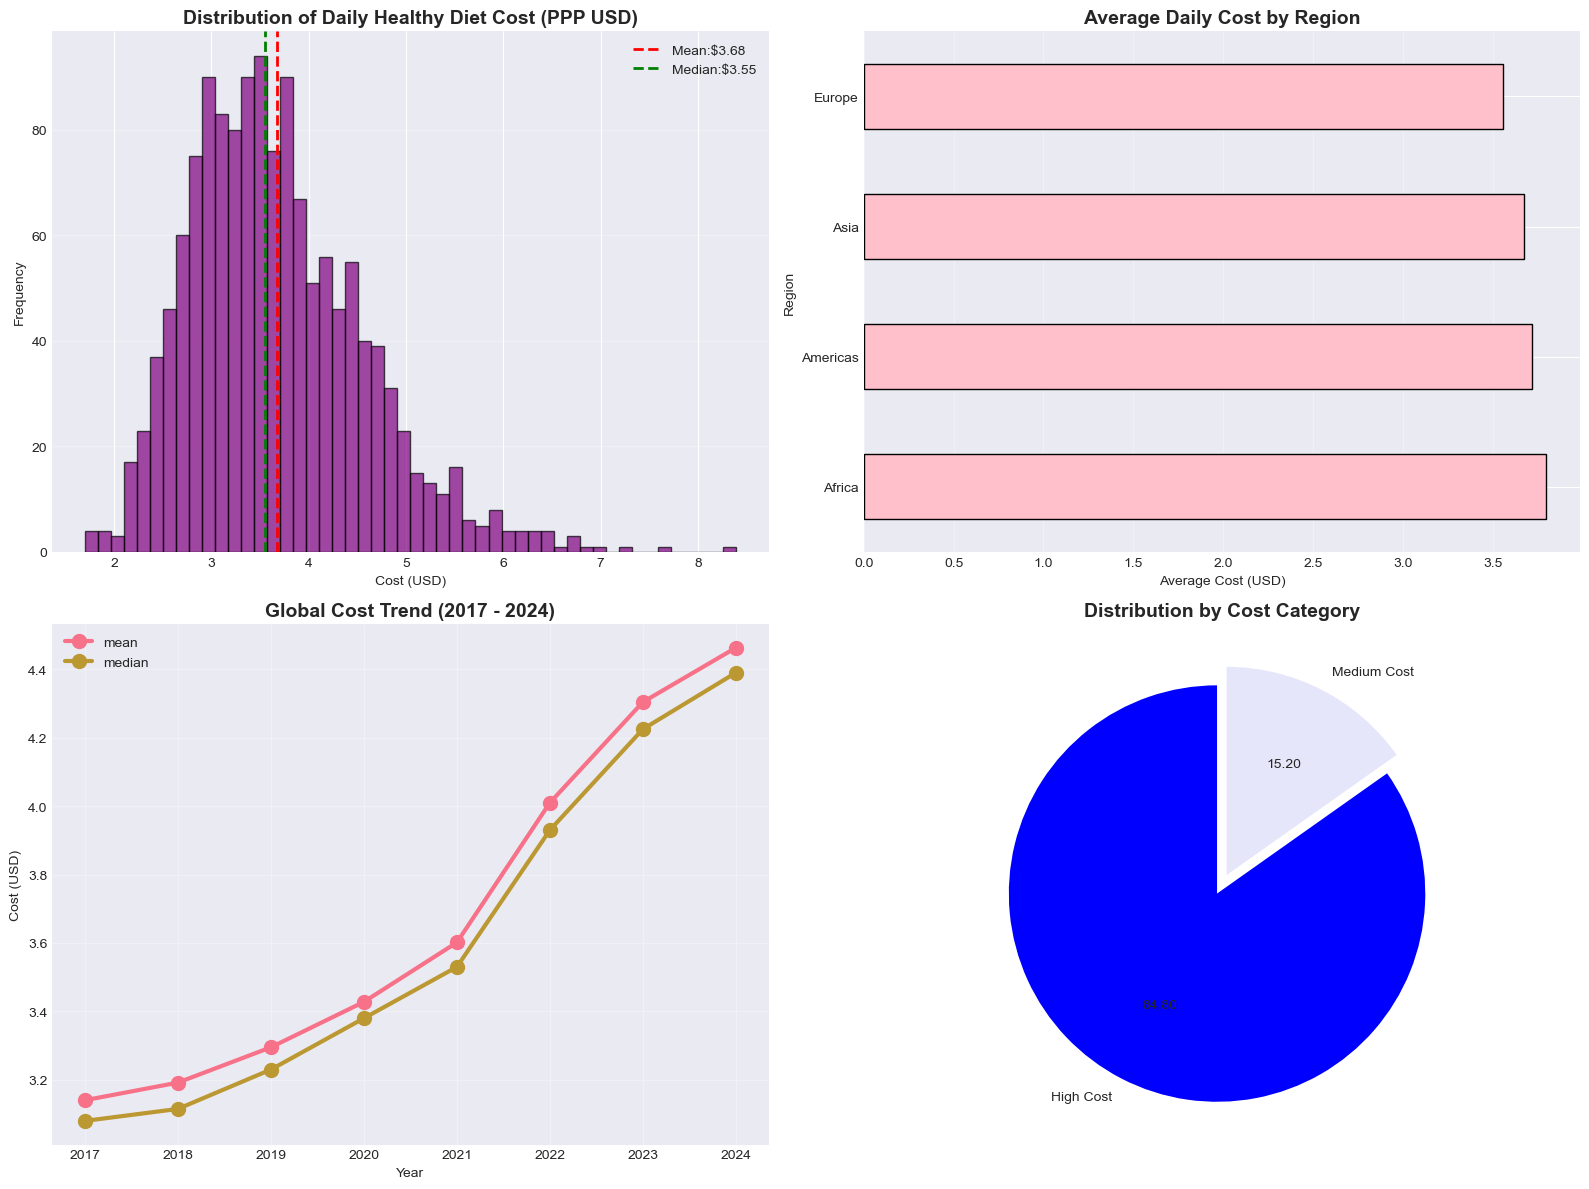

In [83]:
# Global Cost Distribution

fig, axes = plt.subplots(2, 2, figsize=(16,12))

#1. Distribution of healthy diet costs
axes[0, 0].hist(df_clean['cost_healthy_diet_ppp_usd'],bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_clean['cost_healthy_diet_ppp_usd'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean:${df_clean["cost_healthy_diet_ppp_usd"].mean():.2f}')
axes[0, 0].axvline(df_clean['cost_healthy_diet_ppp_usd'].median(), color='green', linestyle='--', linewidth=2, label=f'Median:${df_clean["cost_healthy_diet_ppp_usd"].median():.2f}')
axes[0, 0].set_title('Distribution of Daily Healthy Diet Cost (PPP USD)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cost (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

#2. Cost by Region
if 'region' in df_clean.columns:
    region_cost = df_clean.groupby('region')['cost_healthy_diet_ppp_usd'].mean().sort_values(ascending=False) #groups spending by region and takes the average
    region_cost.plot(kind='barh', ax=axes[0,1], color = 'pink', edgecolor='black') #plots a bar chart of average spending per region
    axes[0,1].set_title('Average Daily Cost by Region', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Average Cost (USD)')
    axes[0,1].set_ylabel('Region')
    axes[0,1].grid(axis='x', alpha=0.3)

#3 Cost Trend over Years
yearly_cost = df_clean.groupby('year')['cost_healthy_diet_ppp_usd'].agg(['mean','median']) #aggregates mean and median of each year
yearly_cost.plot(ax=axes[1,0], marker='o', linewidth=3, markersize=10)
axes[1,0].set_title('Global Cost Trend (2017 - 2024)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Cost (USD)')
axes[1,0].grid(True, alpha=0.3)

#4 Cost Category Distribution
if 'cost_category' in df_clean.columns:
    category_counts = df_clean['cost_category'].value_counts()
    colors = ['blue', 'lavender', 'purple']
    axes[1,1].pie(category_counts, labels=category_counts.index, autopct='%.2f', startangle=90, colors=colors[:len(category_counts)], explode=[0.05]*len(category_counts))
    axes[1,1].set_title('Distribution by Cost Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show

print("\n Key Statistics:")
print(f" Global Average Cost : ${df_clean['cost_healthy_diet_ppp_usd'].mean():.2f}/day")
print(f" Annual Equivalent : ${df_clean['cost_healthy_diet_ppp_usd'].mean() * 365:.2f}/year")
print(f" Cost Range : ${df_clean['cost_healthy_diet_ppp_usd'].min():.2f} - ${df_clean['cost_healthy_diet_ppp_usd'].max():.2f}/day")
print(f" Standard Deviation : ${df_clean['cost_healthy_diet_ppp_usd'].std():.2f}")


 2024 Analysis :

 Most Expensive:
 South Sudan: $8.39/day
 Japan: $7.62/day
 Mongolia: $7.02/day
 Guyana: $6.83/day
 Republic of Korea: $6.68/day

 Most Affordable:
 United Kingdom of Great Britain and Northern Ireland: $2.56/day
 Qatar: $2.66/day
 United States of America: $2.79/day
 Belgium: $2.81/day
 Ireland: $2.83/day


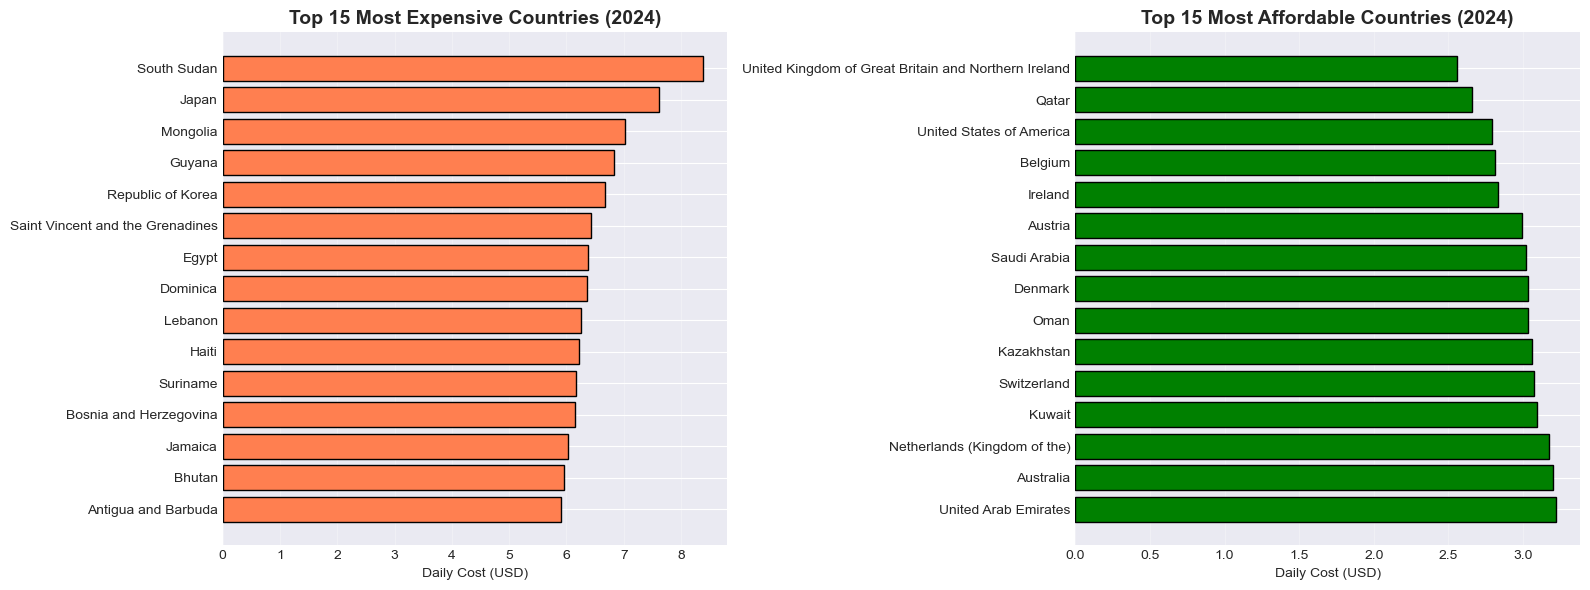

In [84]:
#Analysis of Most Recent Years
latest_year = df_clean['year'].max()
latest_data = df_clean[df_clean['year']== latest_year].copy()

fig, axes = plt.subplots(1, 2, figsize=(16,6))

#15 Most Expensive Countries Data
top_expensive = latest_data.nlargest(15, 'cost_healthy_diet_ppp_usd')[['country', 'cost_healthy_diet_ppp_usd']]
axes[0].barh(top_expensive['country'], top_expensive['cost_healthy_diet_ppp_usd'], color='coral', edgecolor='black')
axes[0].set_title(f'Top 15 Most Expensive Countries ({latest_year})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Daily Cost (USD)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

#15 Most Affordable Countries Data
top_affordable = latest_data.nsmallest(15, 'cost_healthy_diet_ppp_usd')[['country', 'cost_healthy_diet_ppp_usd']]
axes[1].barh(top_affordable['country'], top_affordable['cost_healthy_diet_ppp_usd'], color='green', edgecolor='black')
axes[1].set_title(f'Top 15 Most Affordable Countries ({latest_year})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Daily Cost (USD)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
print(f"\n {latest_year} Analysis :")
print(f"\n Most Expensive:")
for i, row in top_expensive.head(5).iterrows():
    print(f" {row['country']}: ${row['cost_healthy_diet_ppp_usd']:.2f}/day")

print(f"\n Most Affordable:")
for i, row in top_affordable.head(5).iterrows():
    print(f" {row['country']}: ${row['cost_healthy_diet_ppp_usd']:.2f}/day")
    


 Food Component Analysis:
   Average Vegetable Cost: $0.76/day (21.4%)
   Average Fruit Cost: $0.68/day (18.9%)
   Average Other Foods: $2.13/day (59.7%)


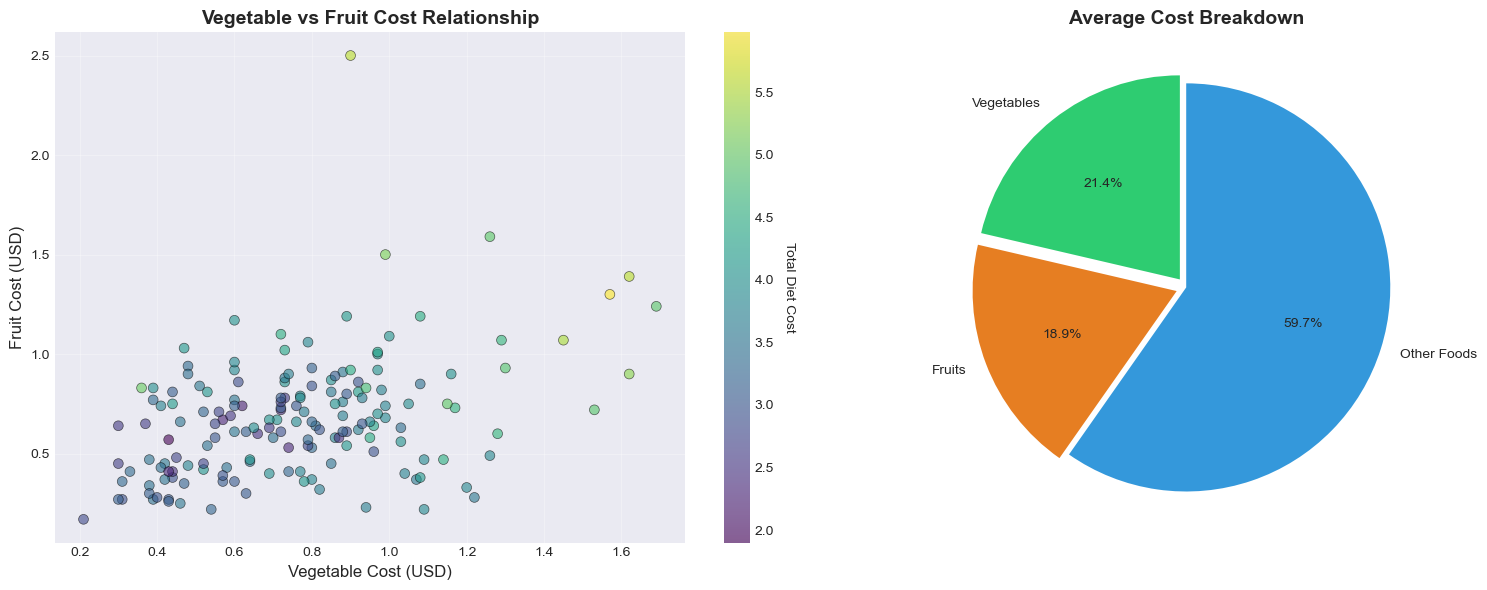

In [85]:
#Analyzing fruit and vegetable costs where available

component_data = df_clean[(df_clean['cost_vegetables_ppp_usd'].notna()) & #detects non missing values in the vegetable cost column
(df_clean['cost_fruits_ppp_usd'].notna())].copy()

if len(component_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    #Scatter: Vegetables vs Fruits cost
    axes[0].scatter(component_data['cost_vegetables_ppp_usd'], component_data['cost_fruits_ppp_usd'], alpha = 0.6, c=component_data['cost_healthy_diet_ppp_usd'],
                    cmap = 'viridis', s=50, edgecolors = 'black', linewidth = 0.5)
    axes[0].set_xlabel('Vegetable Cost (USD)', fontsize=12)
    axes[0].set_ylabel('Fruit Cost (USD)', fontsize=12)
    axes[0].set_title('Vegetable vs Fruit Cost Relationship', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
    cbar.set_label('Total Diet Cost', rotation=270, labelpad=15)

    #Component Contribution
    avg_veg = component_data['cost_vegetables_ppp_usd'].mean()
    avg_fruit = component_data['cost_fruits_ppp_usd'].mean()
    avg_other = component_data['cost_healthy_diet_ppp_usd'].mean() - avg_veg - avg_fruit

    components = ['Vegetables', 'Fruits', 'Other Foods']
    costs = [avg_veg, avg_fruit, avg_other]
    colors_pie = ['#2ecc71', '#e67e22', '#3498db']

    axes[1].pie(costs, labels=components, autopct='%1.1f%%', startangle=90, 
               colors=colors_pie, explode=[0.05, 0.05, 0])
    axes[1].set_title('Average Cost Breakdown', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show

    print("\n Food Component Analysis:")
    print(f"   Average Vegetable Cost: ${avg_veg:.2f}/day ({avg_veg/component_data['cost_healthy_diet_ppp_usd'].mean()*100:.1f}%)")
    print(f"   Average Fruit Cost: ${avg_fruit:.2f}/day ({avg_fruit/component_data['cost_healthy_diet_ppp_usd'].mean()*100:.1f}%)")
    print(f"   Average Other Foods: ${avg_other:.2f}/day ({avg_other/component_data['cost_healthy_diet_ppp_usd'].mean()*100:.1f}%)")

In [86]:
#Machine Learning Pipeline

print("\nStep 1 : Feature Engineering")

#Create the ML dataset
ml_data = df_clean.copy()

#1. Temporal Features
ml_data['years_since_2017'] = ml_data['year'] - 2017
print("Created Column Years Since 2017")

#2. Encode Categorical Variables
le_region = LabelEncoder() #Encodes the strings into a numerical category
le_country = LabelEncoder()
le_category = LabelEncoder()

if 'region' in ml_data.columns:
    ml_data['region_encoded'] = le_region.fit_transform(ml_data['region'].fillna('Unknown'))
    print(f" Encoded: Region ({ml_data['region'].nunique()}categories)")

ml_data['country_encoded'] = le_country.fit_transform(ml_data['country'])
print(f" Encoded: Country ({ml_data['country'].nunique()} countries)")

if 'cost_category' in ml_data.columns:
    ml_data['cost_category_encoded'] = le_category.fit_transform(ml_data['cost_category'].fillna('Unknown'))
    print(f" Encoded: cost_category")

#3. Fill missing component costs with 0 (not measured by surveyors)
if 'cost_vegetables_ppp_usd' in ml_data.columns:
    ml_data['cost_vegetables_ppp_usd'].fillna(0, inplace=True)
if 'cost_fruits_ppp_usd' in ml_data.columns:
    ml_data['cost_fruits_ppp_usd'].fillna(0, inplace=True)
if 'total_food_components_ppp_usd' in ml_data.columns:
    ml_data['total_food_components_ppp_usd'].fillna(0, inplace=True)

#4. Create Interaction Features
if 'region_encoded' in ml_data.columns:
    ml_data['region_year_interaction'] = ml_data['region_encoded'] * ml_data['years_since_2017'] #I think this produces a sort of score which measures something between region and growth?
    print(" Created: region_year_interaction")

#5. Historical Features (Country Level Averages)
country_avg = ml_data.groupby('country_encoded')['cost_healthy_diet_ppp_usd'].transform('mean')
ml_data['country_avg_cost'] = country_avg
print(" Created: country_avg_cost")

print(f"\n Feature Engineering Complete")
print(f" Total Feature Created : {len(ml_data.columns)}")


Step 1 : Feature Engineering
Created Column Years Since 2017
 Encoded: Region (4categories)
 Encoded: Country (175 countries)
 Encoded: cost_category
 Created: region_year_interaction
 Created: country_avg_cost

 Feature Engineering Complete
 Total Feature Created : 17


C:\Users\Idris\AppData\Local\Temp\ipykernel_2984\3483054390.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ml_data['cost_vegetables_ppp_usd'].fillna(0, inplace=True)
C:\Users\Idris\AppData\Local\Temp\ipykernel_2984\3483054390.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [87]:
print("\nStep 2 : Prepare Training Data")

#Define the Feature Columns
feature_cols = [
    'year', 'years_since_2017', 'country_encoded', 'region_encoded',
    'cost_vegetables_ppp_usd', 'cost_fruits_ppp_usd', 
    'total_food_components_cost', 'cost_category_encoded',
    'region_year_interaction', 'country_avg_cost'
]

# Keep Only Available Features
available_features = [f for f in feature_cols if f in ml_data.columns]
print(f" Selected {len(available_features)} features.")

# We drop rows where Target IS NaN OR Any Feature IS NaN
cols_to_check = available_features + ['cost_healthy_diet_ppp_usd']
ml_data_clean = ml_data.dropna(subset=cols_to_check).copy()

X = ml_data_clean[available_features]
y = ml_data_clean['cost_healthy_diet_ppp_usd']

# If 'year' is the same for every row, std_dev is 0, which breaks the scaler.
# We find columns with 0 variance and drop them.
std_devs = X.std()
constant_cols = std_devs[std_devs == 0].index
if len(constant_cols) > 0:
    print(f" WARN: Dropping constant columns (would break scaler): {list(constant_cols)}")
    X = X.drop(columns=constant_cols)

print(f"\n Dataset Prepared:")
print(f" Features Shape : {X.shape}")
print(f" Target Shape   : {y.shape}")

print(f"\n Dataset Prepared:")
print(f" Features Shape : {X.shape}")
print(f" Target Shape : {y.shape}")
print(f" Target Range : ${y.min():.2f} - ${y.max():.2f}")

#Train Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n Training Test Split:")
print(f"Training Set : {len(X_train)} samples")
print(f"Testing Set : {len(X_test)} samples")


#Standardise Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n Features Standardised")



Step 2 : Prepare Training Data
 Selected 10 features.
 WARN: Dropping constant columns (would break scaler): ['year', 'years_since_2017']

 Dataset Prepared:
 Features Shape : (166, 8)
 Target Shape   : (166,)

 Dataset Prepared:
 Features Shape : (166, 8)
 Target Shape : (166,)
 Target Range : $1.90 - $5.98

 Training Test Split:
Training Set : 132 samples
Testing Set : 34 samples

 Features Standardised


In [88]:
print("\nStep 3: Train Multiple Models")

#Dictionary to Store Results
results = {}

#Define Models
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0, random_state=42),
    'Random Forest' : RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=10, random_state =42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimator=100, max_depth=5, learning_rate=0.1,
                                     random_state=42, n_jobs=-1)

if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(n_estimator=100, max_depth=5, learning_rate=0.1,
                                       random_state=42, n_jobs=-1, verbose=-1)

#Train and Evalute Each Model
print(f"\n Training {len(models)} models...\n")

for name, model in models.items():
    print(f"Training {name}...", end=' ')

    #Train
    if name in ['Linear Regression', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    #Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'model' : model,
        'RMSE' : rmse,
        'MAE' : mae,
        'R2' : r2,
        'predictions' : y_pred
    }

    print(f" R^2 : {r2:.4f} | RMSE: {rmse:.3f}")

print("\n All models trained successfully")


Step 3: Train Multiple Models

 Training 6 models...

Training Linear Regression...  R^2 : 0.9601 | RMSE: 0.147
Training Ridge Regression...  R^2 : 0.9603 | RMSE: 0.147
Training Random Forest...  R^2 : 0.9231 | RMSE: 0.204
Training Gradient Boosting...  R^2 : 0.9263 | RMSE: 0.200
Training XGBoost...  R^2 : 0.9011 | RMSE: 0.231
Training LightGBM...  R^2 : 0.8388 | RMSE: 0.295

 All models trained successfully


c:\ProgramData\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:17:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Step 4 : Compare Model Performance

 Model Performance Comparison:
            Model  RMSE  MAE   R2
 Ridge Regression  0.15 0.13 0.96
Linear Regression  0.15 0.13 0.96
Gradient Boosting  0.20 0.16 0.93
    Random Forest  0.20 0.16 0.92
          XGBoost  0.23 0.18 0.90
         LightGBM  0.30 0.20 0.84


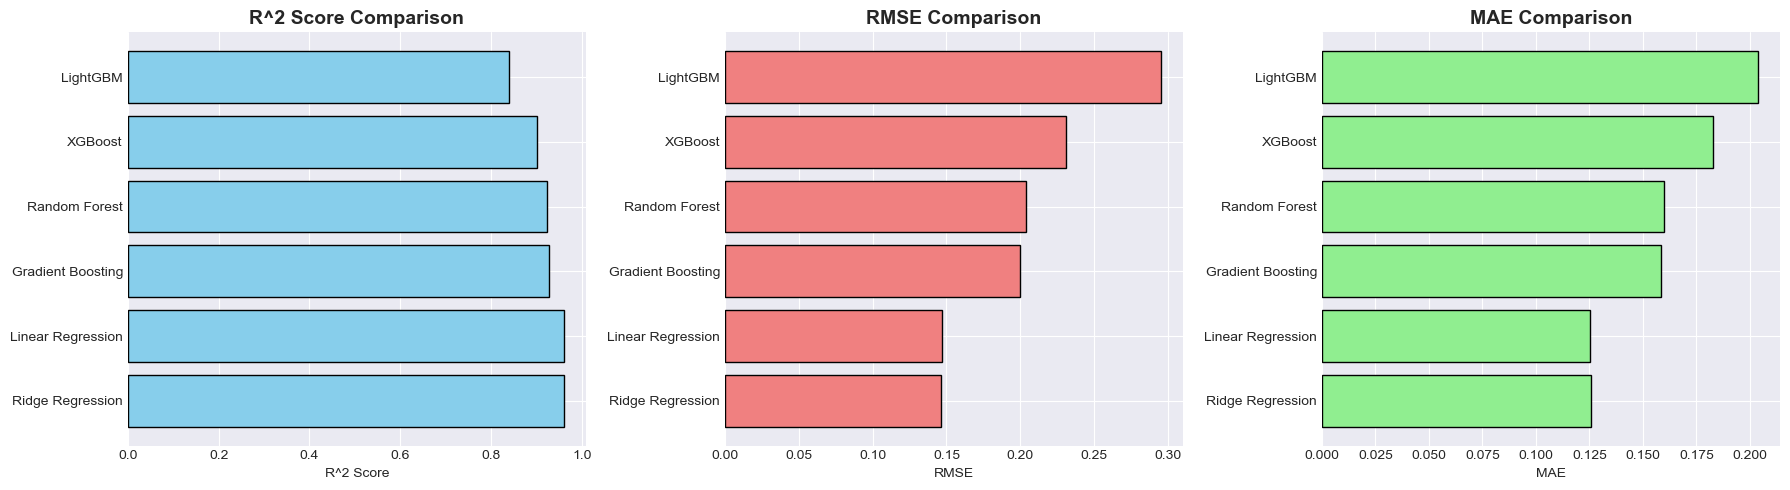


 Best Model: Ridge Regression
 R^2 : 0.9603
 RMSE : 0.147
 MAE : 0.126


In [89]:
print("\nStep 4 : Compare Model Performance")

#Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model' : list(results.keys()),
    'RMSE' : [results[m]['RMSE'] for m in results],
    'MAE' : [results[m]['MAE'] for m in results],
    'R2' : [results[m]['R2'] for m in results]
}).sort_values('R2', ascending=False)

print("\n Model Performance Comparison:")
print(comparison_df.to_string(index=False))

#Visualise Performance
fig, axes = plt.subplots(1, 3, figsize=(18,5))

#R2 score
axes[0].barh(comparison_df['Model'], comparison_df['R2'], color='skyblue', edgecolor='black')
axes[0].set_title('R^2 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R^2 Score')

#RMSE
axes[1].barh(comparison_df['Model'], comparison_df['RMSE'], color='lightcoral', edgecolor='black')
axes[1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE')

#MAE
axes[2].barh(comparison_df['Model'], comparison_df['MAE'], color='lightgreen', edgecolor='black')
axes[2].set_title('MAE Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlabel('MAE')

plt.tight_layout()
plt.show()

#Identify Best Model
best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R2']
best_rmse = comparison_df.iloc[0]['RMSE']
best_mae = comparison_df.iloc[0]['MAE']

print(f"\n Best Model: {best_model_name}")
print(f" R^2 : {best_r2:.4f}")
print(f" RMSE : {best_rmse:.3f}")
print(f" MAE : {best_mae:.3f}")


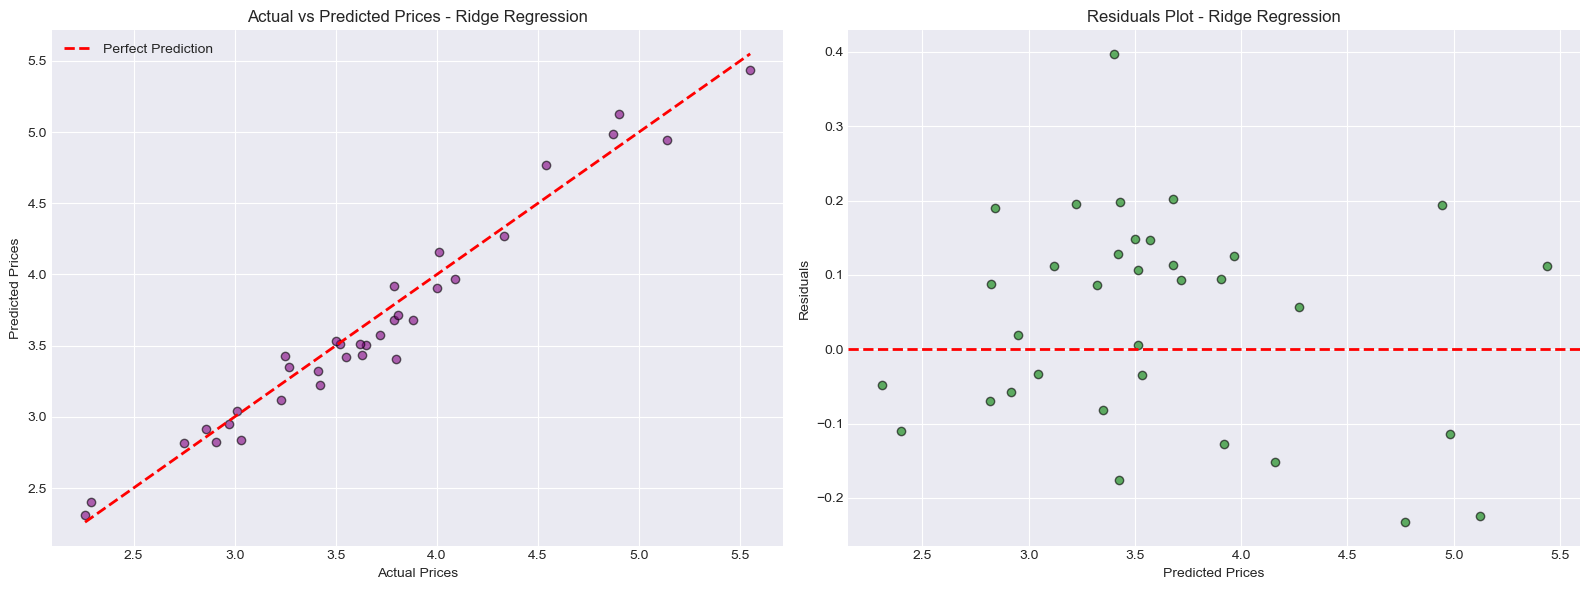

Residual Statistics:
Mean: 0.040
Std Dev: 0.143
Min: -0.233
Max: 0.397


In [90]:
#Visualise Predictions of Best Model (Ridge Regression in this case)
best_predictions = results[best_model_name]['predictions']
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#Actual vs Predicted
axes[0].scatter(y_test, best_predictions, alpha=0.6, color='purple', edgecolor='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Prices')
axes[0].set_ylabel('Predicted Prices')
axes[0].set_title(f'Actual vs Predicted Prices - {best_model_name}')
axes[0].legend()

#Residuals Plot
residuals = y_test - best_predictions
axes[1].scatter(best_predictions, residuals, alpha=0.6, color='green', edgecolor='black')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Prices')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residuals Plot - {best_model_name}')
plt.tight_layout()
plt.show()

print('Residual Statistics:')
print(f'Mean: {residuals.mean():.3f}')
print(f'Std Dev: {residuals.std():.3f}')
print(f'Min: {residuals.min():.3f}')
print(f'Max: {residuals.max():.3f}')

In [91]:
#Feature Importance for Tree-Based Models
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']:
    best_model = results[best_model_name]['model']

    if hasattr(best_model, 'feature_importances_'): #has attribute function
        importance_df = pd.DataFrame({
            'Feature' : available_features,
            'Importance' : best_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        axes[0].figure(figsize=(12,6))
        axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
        axes[0].set_xlabel('Importance')
        axes[0].set_title(f'Feature Importances - {best_model_name}')
        axes[0].invert_yaxis()  # Show most important features at the top
        plt.tight_layout()
        plt.show()

        print(f"\n Top 5 Important Features for {best_model_name}:")
        for i, row in importance_df.head(5).iterrows():
            print(f" {row['Feature']}: {row['Importance']:.4f}")
else:
    print("\n⚠️ Feature importance not available for linear models")


⚠️ Feature importance not available for linear models
